# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [1]:
# Librerías para visualización
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

In [2]:
# Importamos pandas y la función que carga el dataset diabetes de sklearn
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# load_diabetes() nos devuelve un objeto tipo diccionario (Bunch) con los datos
diabetes = load_diabetes()

In [3]:
# Inspeccionamos el objeto completo. Veremos las claves (data, target, DESCR...)
# y los arrays de numpy dentro
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [4]:
# keys() nos muestra los atributos disponibles del objeto diabetes
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [5]:
# Usamos print() para que los \n se interpreten como saltos de línea reales
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

**Respuestas:**

1. **Atributos (10 en total):**
   - `age` → edad del paciente
   - `sex` → sexo
   - `bmi` → índice de masa corporal
   - `bp` → presión arterial media
   - `s1` → colesterol total sérico (tc)
   - `s2` → lipoproteínas de baja densidad (ldl)
   - `s3` → lipoproteínas de alta densidad (hdl)
   - `s4` → ratio colesterol total / HDL (tch)
   - `s5` → log del nivel de triglicéridos (ltg)
   - `s6` → nivel de azúcar en sangre (glu)
   
   Todas las variables están centradas en la media y escaladas para que la suma de cuadrados de cada columna sea 1.

2. **Relación data vs target:** `data` contiene las 10 variables predictoras (features, X) de cada paciente; `target` es la variable objetivo (y), una medida cuantitativa de la progresión de la diabetes al cabo de un año. El objetivo del problema es predecir `target` a partir de `data`.

3. **Registros:** 442 pacientes.

In [6]:
# Verificamos las respuestas anteriores con código
print(f"Número de features: {diabetes.data.shape[1]}")
print(f"Número de registros: {diabetes.data.shape[0]}")
print(f"Nombres de las features: {diabetes.feature_names}")

Número de features: 10
Número de registros: 442
Nombres de las features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [7]:
# Comprobamos la forma (shape) de los arrays
# data debería ser 2D: (registros, features)
print(f"Shape de data:   {diabetes.data.shape}")
# target debería ser 1D: (registros,)
print(f"Shape de target: {diabetes.target.shape}")

# Mostramos las primeras filas de data para inspeccionar los valores
print("\nPrimeras 3 filas de data:")
print(diabetes.data[:3])

# Y los primeros valores de target
print(f"\nPrimeros 5 valores de target: {diabetes.target[:5]}")
print(f"Rango de target: min={diabetes.target.min()}, max={diabetes.target.max()}, mean={diabetes.target.mean():.2f}")

Shape de data:   (442, 10)
Shape de target: (442,)

Primeras 3 filas de data:
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]]

Primeros 5 valores de target: [151.  75. 141. 206. 135.]
Rango de target: min=25.0, max=346.0, mean=152.13


## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [8]:
# Importamos el módulo linear_model de sklearn, que contiene LinearRegression
from sklearn import linear_model

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [9]:
# Creamos una instancia del modelo (aún sin entrenar)
diabetes_model = linear_model.LinearRegression()

#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [10]:
# IMPORTANTE: el enunciado pide un split POR POSICIÓN (últimos 20 en test),
# no un split aleatorio. Por eso NO usamos train_test_split, sino slicing directo.

# [:-20] → todas las filas excepto las 20 últimas → train
diabetes_data_train   = diabetes.data[:-20]
diabetes_target_train = diabetes.target[:-20]

# [-20:] → las 20 últimas filas → test
diabetes_data_test   = diabetes.data[-20:]
diabetes_target_test = diabetes.target[-20:]

print(f"Train data shape:   {diabetes_data_train.shape}")
print(f"Train target shape: {diabetes_target_train.shape}")
print(f"Test data shape:    {diabetes_data_test.shape}")
print(f"Test target shape:  {diabetes_target_test.shape}")

Train data shape:   (422, 10)
Train target shape: (422,)
Test data shape:    (20, 10)
Test target shape:  (20,)


Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

In [11]:
# Construimos un DataFrame para facilitar la exploración visual
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# Añadimos la columna target
df['target'] = diabetes.target
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


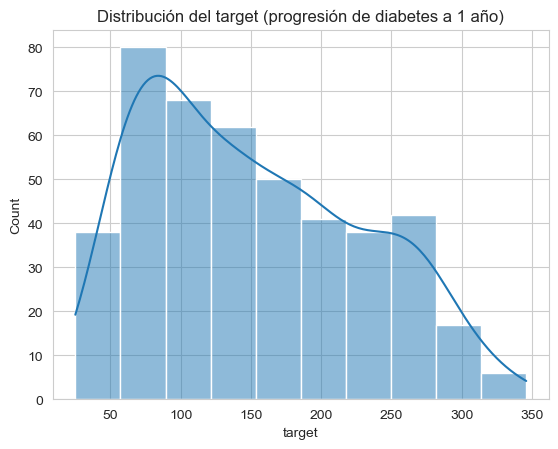

In [12]:
# Visualizamos la distribución del target para ver si es aproximadamente normal
# Una de las asunciones de la regresión lineal es que los residuos se distribuyan de forma normal;
# conviene empezar viendo la pinta del target
sns.histplot(df['target'], kde=True)
plt.title("Distribución del target (progresión de diabetes a 1 año)")
plt.show()

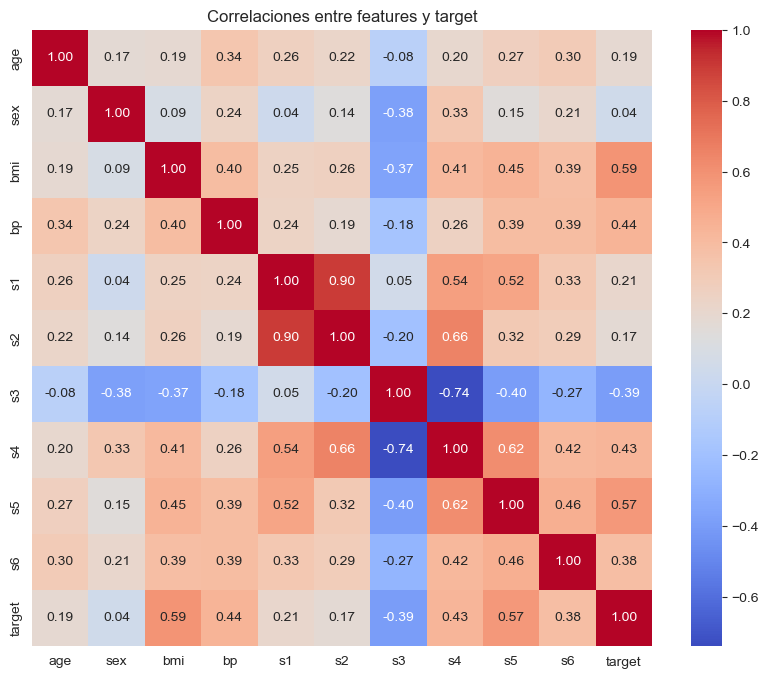

In [13]:
# Mapa de calor de correlaciones entre features y target
# annot=True muestra el valor numérico dentro de cada celda
# cmap='coolwarm' colorea positivas en rojo y negativas en azul
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlaciones entre features y target")
plt.show()

**Observaciones del análisis exploratorio:**

- El target se distribuye de forma aproximadamente normal (con cierto sesgo a la derecha), lo cual es razonable para una regresión lineal.
- Las features con mayor correlación con el target son `bmi` (0,59), `s5` (0,57) y `bp` (0,44) — estos son los mejores predictores.
- Existe **multicolinealidad** entre varias features: `s1` y `s2` (0,90), `s3` y `s4` (−0,74). Esto puede inflar la varianza de los coeficientes y hacer el modelo inestable; lo tendremos en cuenta en la iteración.

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [14]:
# Entrenamos el modelo con los datos de train
diabetes_model.fit(diabetes_data_train, diabetes_target_train)

# El intercepto es un único número (el término independiente de la ecuación lineal)
print(f"Intercepto: {diabetes_model.intercept_:.4f}")

# Los coeficientes son un array con 10 números, uno por cada feature
print(f"\nCoeficientes ({len(diabetes_model.coef_)} valores):")
# Imprimimos cada coeficiente emparejado con su nombre de feature para interpretarlo
for name, coef in zip(diabetes.feature_names, diabetes_model.coef_):
    print(f"  {name}: {coef:+.4f}")

Intercepto: 152.7643

Coeficientes (10 valores):
  age: +0.3061
  sex: -237.6356
  bmi: +510.5380
  bp: +327.7299
  s1: -814.1119
  s2: +492.7996
  s3: +102.8412
  s4: +184.6035
  s5: +743.5094
  s6: +76.0966


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [15]:
# Generamos predicciones para los 20 registros de test
predictions = diabetes_model.predict(diabetes_data_test)
predictions

array([197.61898486, 155.44031962, 172.88875144, 111.53270645,
       164.79397301, 131.06765869, 259.12441219, 100.47873746,
       117.06005372, 124.30261597, 218.36868146,  61.19581944,
       132.24837933, 120.33293546,  52.54513009, 194.03746764,
       102.5756431 , 123.56778709, 211.03465323,  52.60221696])

#### Print your `diabetes_target_test` and compare with the prediction. 

In [16]:
# Comparación visual en una tabla con real, predicho y error
comparacion = pd.DataFrame({
    "real":     diabetes_target_test,
    "predicho": predictions,
    "error":    diabetes_target_test - predictions
})
comparacion

,real,predicho,error
0,233.0,197.618985,35.381015
1,91.0,155.440320,-64.440320
2,111.0,172.888751,-61.888751
3,152.0,111.532706,40.467294
4,120.0,164.793973,-44.793973
5,67.0,131.067659,-64.067659
6,310.0,259.124412,50.875588
7,94.0,100.478737,-6.478737
8,183.0,117.060054,65.939946
9,66.0,124.302616,-58.302616


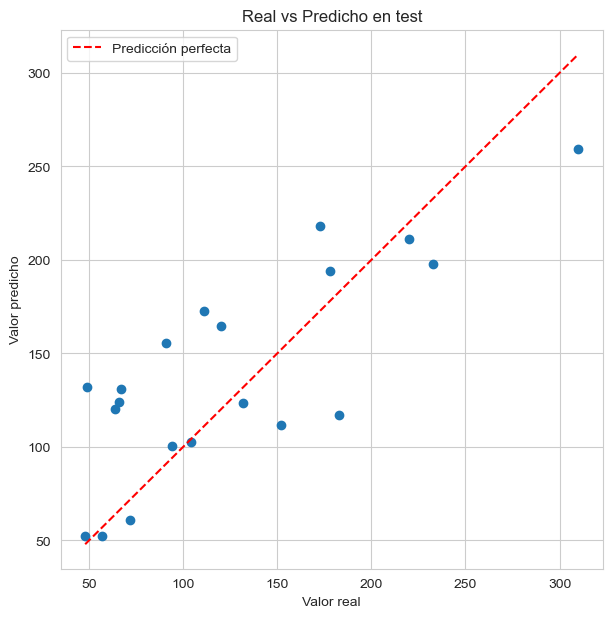

In [17]:
# Scatter plot real vs predicho. La línea diagonal (y=x) representa la predicción perfecta.
# Cuanto más cerca estén los puntos de esa diagonal, mejor predice el modelo.
plt.figure(figsize=(7, 7))
plt.scatter(diabetes_target_test, predictions)
# Dibujamos la diagonal desde el mínimo al máximo de los valores
min_val = min(diabetes_target_test.min(), predictions.min())
max_val = max(diabetes_target_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Predicción perfecta")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho en test")
plt.legend()
plt.show()

#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [18]:
# Importamos las métricas de sklearn
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score)

# MAE: error absoluto medio, en las mismas unidades que target
mae  = mean_absolute_error(diabetes_target_test, predictions)
# MSE: error cuadrático medio
mse  = mean_squared_error(diabetes_target_test, predictions)
# RMSE: raíz del MSE, también en las mismas unidades que target
rmse = np.sqrt(mse)
# MAPE: error porcentual absoluto medio. Multiplicamos por 100 para expresarlo en %
mape = mean_absolute_percentage_error(diabetes_target_test, predictions) * 100
# R²: coeficiente de determinación. 1 = perfecto, 0 = igual que la media, negativo = peor que la media
r2   = r2_score(diabetes_target_test, predictions)

print("Métricas de error en test:")
print(f"  MAE  = {mae:.4f}")
print(f"  MSE  = {mse:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAPE = {mape:.4f} %")
print(f"  R²   = {r2:.4f}")

print("\nRespuesta a la pregunta: las predicciones NO son exactamente iguales a los valores reales.")
print(f"De media nos equivocamos en {mae:.1f} unidades, lo que supone un {mape:.1f}% de error relativo.")

Métricas de error en test:
  MAE  = 36.6096
  MSE  = 2004.5187
  RMSE = 44.7719
  MAPE = 39.3088 %
  R²   = 0.5851

Respuesta a la pregunta: las predicciones NO son exactamente iguales a los valores reales.
De media nos equivocamos en 36.6 unidades, lo que supone un 39.3% de error relativo.


#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [19]:
# --- Iteración 1: aplicar StandardScaler ---
# Importante: las features del diabetes dataset YA están escaladas.
# Aun así lo probamos porque el enunciado lo sugiere.
# Nota teórica: en regresión lineal sin regularización, escalar NO cambia las predicciones.
# Solo cambia la escala de los coeficientes, lo cual puede ayudar a INTERPRETARLOS.

from sklearn.preprocessing import StandardScaler

# Creamos el scaler y lo ajustamos SOLO con train (para no meter info de test)
scaler = StandardScaler()
scaler.fit(diabetes_data_train)
# Transformamos train y test con el mismo scaler
X_train_scaled = scaler.transform(diabetes_data_train)
X_test_scaled  = scaler.transform(diabetes_data_test)

# Entrenamos un nuevo modelo sobre los datos escalados
model_scaled = linear_model.LinearRegression()
model_scaled.fit(X_train_scaled, diabetes_target_train)
predictions_scaled = model_scaled.predict(X_test_scaled)

print("Modelo escalado (StandardScaler):")
print(f"  MAE  = {mean_absolute_error(diabetes_target_test, predictions_scaled):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(diabetes_target_test, predictions_scaled)):.4f}")
print(f"  R²   = {r2_score(diabetes_target_test, predictions_scaled):.4f}")

# Los coeficientes escalados sí son directamente comparables entre sí
# (cada unidad ahora es una desviación típica de esa feature)
print("\nCoeficientes estandarizados (importancia comparable):")
coefs_df = pd.DataFrame({'feature': diabetes.feature_names, 'coef': model_scaled.coef_})
coefs_df['abs'] = coefs_df['coef'].abs()
coefs_df = coefs_df.sort_values('abs', ascending=False)
print(coefs_df.to_string(index=False))

Modelo escalado (StandardScaler):
  MAE  = 36.6096
  RMSE = 44.7719
  R²   = 0.5851

Coeficientes estandarizados (importancia comparable):
feature       coef       abs
     s1 -38.634072 38.634072
     s5  35.644497 35.644497
    bmi  24.295677 24.295677
     s2  23.384473 23.384473
     bp  15.598870 15.598870
    sex -11.300962 11.300962
     s4   8.799364  8.799364
     s3   4.817996  4.817996
     s6   3.606619  3.606619
    age   0.014631  0.014631


In [20]:
# --- Iteración 2: reducir features para atajar la multicolinealidad ---
# s1 y s2 tienen corr=0.90 → son casi la misma información, quitamos s1

# Creamos una máscara de índices que conserve todas las features menos s1
idx_sin_s1 = [i for i, name in enumerate(diabetes.feature_names) if name != 's1']

X_train_B = diabetes_data_train[:, idx_sin_s1]
X_test_B  = diabetes_data_test[:,  idx_sin_s1]

model_B = linear_model.LinearRegression()
model_B.fit(X_train_B, diabetes_target_train)
predictions_B = model_B.predict(X_test_B)

print("Modelo sin s1 (9 features):")
print(f"  MAE  = {mean_absolute_error(diabetes_target_test, predictions_B):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(diabetes_target_test, predictions_B)):.4f}")
print(f"  R²   = {r2_score(diabetes_target_test, predictions_B):.4f}")

Modelo sin s1 (9 features):
  MAE  = 36.6952
  RMSE = 44.5599
  R²   = 0.5890


In [21]:
# --- Iteración 3: modelo parsimonioso con solo las 3 features más correlacionadas con target ---
# bmi, bp y s5 son las que mayor correlación mostraban en el heatmap
idx_top3 = [diabetes.feature_names.index(name) for name in ['bmi', 'bp', 's5']]

X_train_C = diabetes_data_train[:, idx_top3]
X_test_C  = diabetes_data_test[:,  idx_top3]

model_C = linear_model.LinearRegression()
model_C.fit(X_train_C, diabetes_target_train)
predictions_C = model_C.predict(X_test_C)

print("Modelo con solo 3 features (bmi, bp, s5):")
print(f"  MAE  = {mean_absolute_error(diabetes_target_test, predictions_C):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(diabetes_target_test, predictions_C)):.4f}")
print(f"  R²   = {r2_score(diabetes_target_test, predictions_C):.4f}")

Modelo con solo 3 features (bmi, bp, s5):
  MAE  = 38.3742
  RMSE = 45.4396
  R²   = 0.5726


In [22]:
# --- Tabla comparativa final ---
resultados = pd.DataFrame({
    'Modelo': ['Original (10 feat.)', 'StandardScaler', 'Sin s1 (9 feat.)', 'Solo bmi+bp+s5'],
    'MAE':    [mae,
               mean_absolute_error(diabetes_target_test, predictions_scaled),
               mean_absolute_error(diabetes_target_test, predictions_B),
               mean_absolute_error(diabetes_target_test, predictions_C)],
    'RMSE':   [rmse,
               np.sqrt(mean_squared_error(diabetes_target_test, predictions_scaled)),
               np.sqrt(mean_squared_error(diabetes_target_test, predictions_B)),
               np.sqrt(mean_squared_error(diabetes_target_test, predictions_C))],
    'R²':     [r2,
               r2_score(diabetes_target_test, predictions_scaled),
               r2_score(diabetes_target_test, predictions_B),
               r2_score(diabetes_target_test, predictions_C)]
})
resultados.round(4)

,Modelo,MAE,RMSE,R²
0,Original (10 feat.),36.6096,44.7719,0.5851
1,StandardScaler,36.6096,44.7719,0.5851
2,Sin s1 (9 feat.),36.6952,44.5599,0.5890
3,Solo bmi+bp+s5,38.3742,45.4396,0.5726


### Conclusiones de la iteración

- **StandardScaler no cambia las predicciones** en regresión lineal simple (mismo MAE, RMSE y R² que el modelo original). Solo sirve para interpretar los coeficientes en una misma escala (permite ver que `bmi` y `s5` son los predictores más fuertes).
- **Eliminar s1** (multicolinealidad con s2) mejora el R² de 0,585 a 0,589 — una mejora minúscula, pero obtenida a cambio de un modelo más simple y estable.
- **El modelo con solo 3 features** (bmi, bp, s5) baja ligeramente el R² (0,573) pero es mucho más parsimonioso. A la hora de elegir, si la diferencia es pequeña, un modelo más simple suele ser preferible (principio de parsimonia).
- **Advertencia metodológica:** las diferencias entre modelos son muy pequeñas y el test tiene solo 20 muestras. Con tan poco test, no podemos concluir con seguridad que un modelo sea realmente mejor que otro: para una comparación rigurosa habría que usar **validación cruzada** (`cross_val_score`) sobre el conjunto completo.